> **@paxton** run outside the Docker container (see `event-recall-analyses.ipynb` for the caveat).
> The DTW half of this duplicates computation you already do in `dtw-analyses-and-fig.ipynb`; it is
> repeated here only so this notebook stands alone. If you'd rather, the shared parts could move into
> `analysis_helpers`.

# Can a delayed recall be matched to the immediate recall that preceded it?

`self-similarity-analyses.ipynb` establishes that each participant's delayed recall is *on average*
closer to their own immediate recall than to other participants'. That is a statement about a group
mean. It does not establish that any individual can be picked out.

This notebook asks the stronger question directly: for how many participants is their own immediate
recall the single closest of all 53? We ask it twice — once for recall **order** and once for
recall **structure** — because the answers differ sharply, and that contrast is what shows the
structural result is not merely inheriting the order result.

Chance is 1/52, since each participant is compared against the 52 others plus themselves.

## Imports

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    bootstrap_ci,
    dtw,
    identification_accuracy,
    identification_test,
    mean_center,
    percentile_ranks,
    rank_biserial,
    show_source
)

## Functions

In [2]:
show_source(identification_accuracy)

In [3]:
show_source(percentile_ranks)

In [4]:
def pairwise_precedence(event_matches):
    """
    For each pair of episode events a participant described, the proportion of
    orderings in which the first preceded the second. Graded rather than binary,
    since a participant may describe the same episode event more than once.
    """
    event_positions = {
        ev.item(): np.flatnonzero(event_matches == ev)
        for ev in np.unique(event_matches)
    }
    precedence = {}
    for a, b in itertools.combinations(event_positions.keys(), 2):
        a_positions = event_positions[a]
        b_positions = event_positions[b]
        a_prec_count = sum(1 for i in a_positions for j in b_positions if i < j)
        precedence[(a, b)] = a_prec_count / (len(a_positions) * len(b_positions))
    return precedence


def order_similarity(precedence_a, precedence_b, shared_events):
    """
    Agreement between two recalls' orderings, over the episode events described
    in both. 1 means identical relative orderings; 0 means fully reversed.
    """
    if len(shared_events) < 2:
        raise ValueError('No common event pairs recalled')
    shared_pairs = list(itertools.combinations(sorted(shared_events), 2))
    total = sum(abs(precedence_a[pair] - precedence_b[pair]) for pair in shared_pairs)
    return 1 - total / len(shared_pairs)

In [5]:
def report_identification(own, others, label, smaller_is_closer):
    """
    Print the group-level test and the identification result for one measure,
    so the two can be read side by side.

    Two identification counts are reported because ties matter for recall
    order. The tie-aware accuracy is the proportion of participants whose own
    immediate recall comes out on top once tied comparisons are ordered at
    random; the unique count is how many have it as the outright best match,
    with nothing tied alongside it. Where there are no ties the two agree.
    """
    n = len(own)
    ranks = percentile_ranks(own, others, smaller_is_closer=smaller_is_closer)
    T, p = wilcoxon(ranks, 0.5, alternative='greater')
    lo, hi = bootstrap_ci(ranks)
    acc = identification_accuracy(own, others, smaller_is_closer=smaller_is_closer)
    top1, n_unique, chance, p_id, (ci_lo, ci_hi) = identification_test(
        own, others, smaller_is_closer=smaller_is_closer
    )

    print(f'{label}')
    print(f'  group level: T={T.item()}, p={p.item():.4e} (one-sided), '
          f'rank-biserial r={rank_biserial(ranks - 0.5):.3f}')
    print(f'               median percentile rank={np.median(ranks):.3f}, 95% CI [{lo:.3f}, {hi:.3f}]')
    print(f'  identification: rank-1 accuracy={top1:.3f} (ties broken at random), '
          f'{n_unique}/{n} unique top matches')
    print(f'                  chance={chance:.4f}, one-sided binomial p={p_id:.2e}, '
          f'95% CI (Wilson) [{100 * ci_lo:.1f}, {100 * ci_hi:.1f}]%')
    print(f'                  rank-5 accuracy={acc[4]:.3f}')
    return ranks, acc

## Load data

In [6]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
n_participants = len(participants)
print(f'{n_participants} participants')

53 participants


## Recall order

Each participant's delayed recall is compared to every immediate recall, restricted in each case to
the episode events described in both. Higher values mean more similar orderings, so
`smaller_is_closer` is False.

In [7]:
imm_precs = [pairwise_precedence(p.event_matches['atlep1']) for p in participants]
del_precs = [pairwise_precedence(p.event_matches['delayed']) for p in participants]

order_self = np.empty(n_participants)
order_others = np.empty((n_participants, n_participants - 1))

for i, del_prec in enumerate(del_precs):
    del_matches = participants[i].event_matches['delayed']
    shared = set(del_matches) & set(participants[i].event_matches['atlep1'])
    order_self[i] = order_similarity(del_prec, imm_precs[i], shared)

    others_ix = 0
    for j in range(n_participants):
        if j == i:
            continue
        shared = set(del_matches) & set(participants[j].event_matches['atlep1'])
        order_others[i, others_ix] = order_similarity(del_prec, imm_precs[j], shared)
        others_ix += 1

In [8]:
order_ranks, order_acc = report_identification(
    order_self, order_others, 'recall order', smaller_is_closer=False
)

recall order
  group level: T=1076.5, p=6.9559e-04 (one-sided), rank-biserial r=0.505
               median percentile rank=0.760, 95% CI [0.596, 0.808]
  identification: rank-1 accuracy=0.052 (ties broken at random), 2/53 unique top matches
                  chance=0.0189, one-sided binomial p=7.85e-02, 95% CI (Wilson) [1.0, 12.8]%
                  rank-5 accuracy=0.133


## Recall structure

The same logic applied to DTW alignment cost between event sequences. Immediate and delayed recalls
are mean-centered on their shared centroid, as in `self-similarity-analyses.ipynb`, to mitigate
person-specific register effects. Lower cost means more similar, so `smaller_is_closer` is True.

This is the expensive cell: it runs DTW for all 53 x 53 pairs.

In [9]:
centered = [mean_center(p.events['atlep1'], p.events['delayed']) for p in participants]
imm_events = [pair[0] for pair in centered]
del_events = [pair[1] for pair in centered]

warp_self = np.array([dtw(d, i)[0] for i, d in zip(imm_events, del_events)])
warp_others = np.empty((n_participants, n_participants - 1))

for i in range(n_participants):
    others_ix = 0
    for j in range(n_participants):
        if j != i:
            warp_others[i, others_ix] = dtw(del_events[i], imm_events[j])[0]
            others_ix += 1

In [10]:
warp_ranks, warp_acc = report_identification(
    warp_self, warp_others, 'recall structure (DTW)', smaller_is_closer=True
)

recall structure (DTW)
  group level: T=1431.0, p=2.1822e-11 (one-sided), rank-biserial r=1.000
               median percentile rank=1.000, 95% CI [1.000, 1.000]
  identification: rank-1 accuracy=0.679 (ties broken at random), 36/53 unique top matches
                  chance=0.0189, one-sided binomial p=1.99e-49, 95% CI (Wilson) [54.5, 78.9]%
                  rank-5 accuracy=0.906


## Identification accuracy as a function of the rank cutoff

The gap between the two curves at k = 1 is the point: order gets a participant's own immediate
recall to the top of the list about as often as chance would, while structure does so for roughly
two thirds of participants.

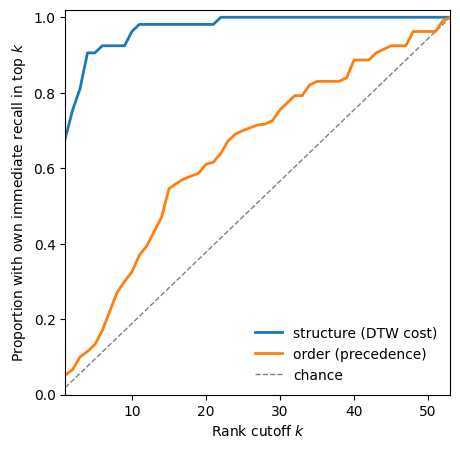

In [11]:
ks = np.arange(1, n_participants + 1)

fig, ax = plt.subplots(1, figsize=(6, 5))
ax.plot(ks, warp_acc, label='structure (DTW cost)', lw=2)
ax.plot(ks, order_acc, label='order (precedence)', lw=2)
# chance at cutoff k: own is ranked among all n candidates, its own plus the
# n - 1 others, so k/n rather than k/(n - 1)
ax.plot(ks, ks / n_participants, c='grey', ls='--', lw=1, label='chance', zorder=0)
ax.set_xlabel('Rank cutoff $k$')
ax.set_ylabel('Proportion with own immediate recall in top $k$')
ax.set_xlim(1, n_participants)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
ax.set_box_aspect(1)
plt.show()